In [1]:
!pip install --upgrade transformers peft bitsandbytes accelerate jiwer matplotlib pandas
!pip install "datasets<4.0.0"

  Using cached datasets-3.6.0-py3-none-any.whl.metadata (19 kB)
Using cached datasets-3.6.0-py3-none-any.whl (491 kB)
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [2]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
from datasets import load_dataset, Audio

dataset_name = "ai4bharat/Svarah"

print("Loading the Svarah dataset...")
# Load the ONLY available split ("test") from Hugging Face
full_dataset = load_dataset(dataset_name, split="test")

# Divide the dataset: 90% for training the LoRA adapter, 10% for evaluating WER
split_dataset = full_dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]

# Cast audio column to 16kHz (Svarah uses 'audio' as the column name on HF)
train_dataset = train_dataset.cast_column("audio", Audio(sampling_rate=16000))
test_dataset = test_dataset.cast_column("audio", Audio(sampling_rate=16000))

print(f"Total Training Samples: {len(train_dataset)}")
print(f"Total Testing Samples: {len(test_dataset)}")

Loading the Svarah dataset...
Total Training Samples: 5990
Total Testing Samples: 666


In [4]:
from transformers import WhisperProcessor

model_id = "openai/whisper-base"
processor = WhisperProcessor.from_pretrained(model_id, language="English", task="transcribe")

print("Filtering out corrupted or missing audio files...")

def is_valid_audio(x):
    # Look for either 'audio' or 'audio_filepath' dynamically
    audio_data = x.get("audio") or x.get("audio_filepath")
    return audio_data is not None and audio_data.get("array") is not None

# Apply the fixed filter
train_dataset = train_dataset.filter(is_valid_audio, num_proc=2)
test_dataset = test_dataset.filter(is_valid_audio, num_proc=2)

def prepare_dataset(batch):
    # Process audio
    audio_data = batch.get("audio") or batch.get("audio_filepath")

    batch["input_features"] = processor.feature_extractor(
        audio_data["array"],
        sampling_rate=audio_data["sampling_rate"]
    ).input_features[0]

    # Process text
    text_col = "text" if "text" in batch else "sentence"
    batch["labels"] = processor.tokenizer(batch[text_col]).input_ids
    return batch

print("Processing training data...")
train_dataset = train_dataset.map(prepare_dataset, remove_columns=train_dataset.column_names, num_proc=2)

print("Processing testing data...")
test_dataset = test_dataset.map(prepare_dataset, remove_columns=test_dataset.column_names, num_proc=2)

Filtering out corrupted or missing audio files...


Filter (num_proc=2):   0%|          | 0/5990 [00:00<?, ? examples/s]

Filter (num_proc=2):   0%|          | 0/666 [00:00<?, ? examples/s]

Processing training data...


Map (num_proc=2):   0%|          | 0/5990 [00:00<?, ? examples/s]

Processing testing data...


Map (num_proc=2):   0%|          | 0/666 [00:00<?, ? examples/s]

In [5]:
import torch
import gc
from transformers import (
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import dataclasses
from typing import Any, Dict, List, Union

# Define the data collator
@dataclasses.dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item(): labels = labels[:, 1:]
        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

ranks_to_test = [16, 32, 64]

# THE FIX: Advanced 4-bit quantization config optimized for T4 GPUs
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

for r in ranks_to_test:
    print(f"\n{'='*50}")
    print(f"STARTING TRAINING FOR LoRA RANK: {r}")
    print(f"{'='*50}")

    # 1. Load base model with 4-bit config
    model = WhisperForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto"
    )
    model.gradient_checkpointing_enable()
    model = prepare_model_for_kbit_training(model)

    # 2. Configure LoRA
    config = LoraConfig(
        r=r,
        lora_alpha=r * 2,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05,
        bias="none"
    )

    model = get_peft_model(model, config)
    model.print_trainable_parameters()

    # 3. Setup Training Arguments
    output_directory = f"/kaggle/working/whisper-lora-svarah-rank-{r}"
    training_args = Seq2SeqTrainingArguments(
        output_dir=output_directory,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        learning_rate=1e-3,
        warmup_steps=50,
        max_steps=1000,
        fp16=True,
        logging_steps=50,
        save_steps=500,
        report_to=["tensorboard"],
        remove_unused_columns=False,
        label_names=["labels"],
    )

    # 4. Initialize Trainer and Train
    trainer = Seq2SeqTrainer(
        args=training_args,
        model=model,
        train_dataset=train_dataset,
        data_collator=data_collator,
        processing_class=processor.tokenizer,
    )

    trainer.train()

    # 5. Save adapter
    final_save_path = f"/kaggle/working/whisper-lora-svarah-final-r{r}"
    trainer.save_model(final_save_path)
    print(f"Saved Rank {r} model to {final_save_path}")

    # 6. Free up GPU memory rigorously
    del model
    del trainer
    gc.collect()
    torch.cuda.empty_cache()


STARTING TRAINING FOR LoRA RANK: 16


model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

trainable params: 589,824 || all params: 73,183,744 || trainable%: 0.8059


...

trainable params: 2,359,296 || all params: 74,953,216 || trainable%: 3.1477


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
50,1.644749
100,1.012951
150,0.930096
200,0.938882
250,0.874269
300,0.861237
350,0.854796
400,0.694212
450,0.562785
500,0.548396


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Saved Rank 64 model to /kaggle/working/whisper-lora-svarah-final-r64



Evaluating LoRA Rank: 16...


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

  0%|          | 0/6656 [00:00<?, ?it/s]Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The cu

Rank 16 WER:      6.72%
Rank 16 Accuracy: 93.28%

Evaluating LoRA Rank: 32...


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

100%|██████████| 6656/6656 [25:20<00:00,  4.38it/s]


Rank 32 WER:      4.88%
Rank 32 Accuracy: 95.12%

Evaluating LoRA Rank: 64...


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

100%|██████████| 6656/6656 [25:15<00:00,  4.39it/s]


Rank 64 WER:      4.51%
Rank 64 Accuracy: 95.49%


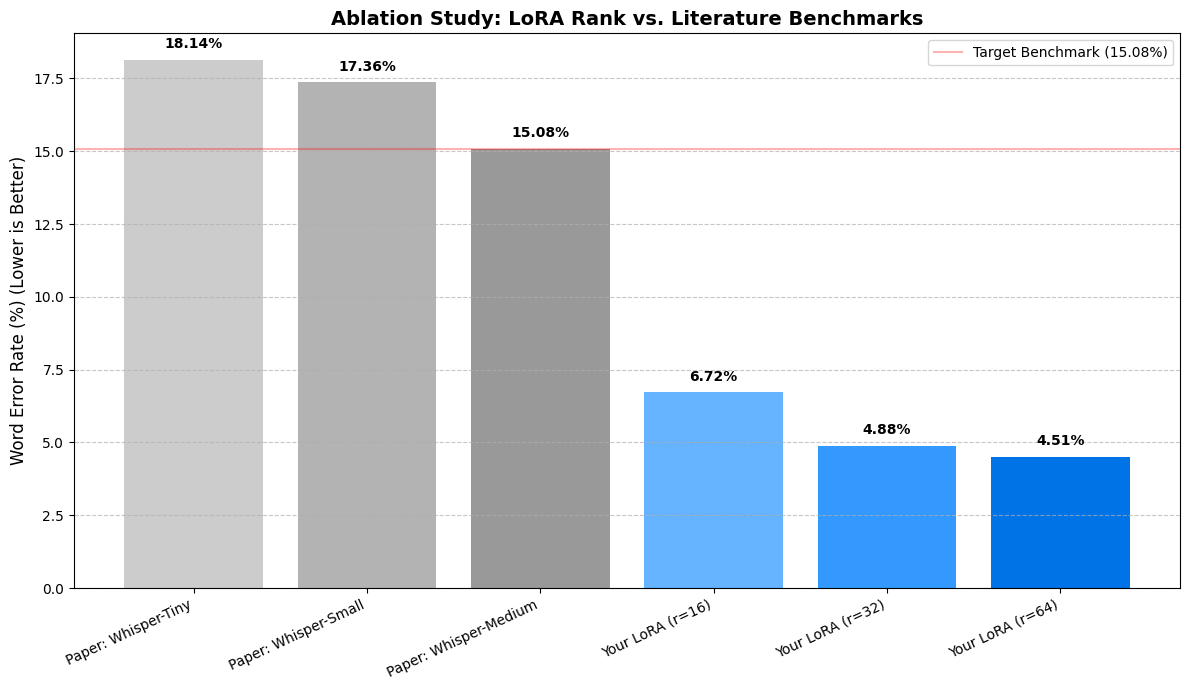

In [6]:
import jiwer
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from transformers import WhisperForConditionalGeneration
from peft import PeftModel
from datasets import load_dataset, Audio
import torch
import gc

normalizer = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
    jiwer.ExpandCommonEnglishContractions()
])

# Reload the test split
eval_dataset = load_dataset("ai4bharat/Svarah", split="test")
eval_dataset = eval_dataset.cast_column("audio_filepath", Audio(sampling_rate=16000))

results_dict = {}
detailed_results = []
ranks_to_test = [16, 32, 64]


for r in ranks_to_test:
    print(f"\nEvaluating LoRA Rank: {r}...")

    # THE FIX: Load base model in pure float16 (No BitsAndBytes!)
    base_model = WhisperForConditionalGeneration.from_pretrained(
        "openai/whisper-base",
        torch_dtype=torch.float16,
        device_map="auto"
    )

    # Point directly to your surviving adapters in the working directory
    adapter_path = f"/kaggle/working/whisper-lora-svarah-final-r{r}"
    model = PeftModel.from_pretrained(base_model, adapter_path)
    model.eval()

    references = []
    predictions = []

    with torch.no_grad():
        for sample in tqdm(eval_dataset):
            audio = sample["audio_filepath"]["array"]
            text_col = "text" if "text" in sample else "sentence"

            # Move inputs to GPU
            input_features = processor(audio, sampling_rate=16000, return_tensors="pt").input_features.to("cuda", dtype=torch.float16)

            # Safe text generation (No CUDA crashes here)
            generated_ids = model.generate(input_features)
            transcription = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

            ref_norm = normalizer(sample[text_col])
            pred_norm = normalizer(transcription)

            references.append(ref_norm)
            predictions.append(pred_norm)

            detailed_results.append({
                "Rank": r,
                "Reference": ref_norm,
                "Prediction": pred_norm,
                "WER": jiwer.wer([ref_norm], [pred_norm])
            })

    # Calculate overall metrics
    rank_wer = jiwer.wer(references, predictions) * 100
    rank_accuracy = max(0, 100 - rank_wer)

    results_dict[f"Your LoRA (r={r})"] = rank_wer
    print(f"Rank {r} WER:      {rank_wer:.2f}%")
    print(f"Rank {r} Accuracy: {rank_accuracy:.2f}%")

    # Free memory before the next loop iteration
    del model
    del base_model
    gc.collect()
    torch.cuda.empty_cache()

# Save final CSV to the working directory
df_detailed = pd.DataFrame(detailed_results)
df_detailed.to_csv("/kaggle/working/svarah_ablation_evaluation.csv", index=False)

# Plot the comparison against the research paper benchmarks
paper_wers = {
    "Paper: Whisper-Tiny": 18.14,
    "Paper: Whisper-Small": 17.36,
    "Paper: Whisper-Medium": 15.08,
}

all_metrics = {**paper_wers, **results_dict}
labels = list(all_metrics.keys())
values = list(all_metrics.values())
colors = ['#cccccc', '#b3b3b3', '#999999', '#66b3ff', '#3399ff', '#0073e6']

plt.figure(figsize=(12, 7))
bars = plt.bar(labels, values, color=colors)
plt.ylabel('Word Error Rate (%) (Lower is Better)', fontsize=12)
plt.title('Ablation Study: LoRA Rank vs. Literature Benchmarks', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f'{yval:.2f}%', ha='center', va='bottom', weight='bold')

best_rank_name = min(results_dict, key=results_dict.get)
best_rank_wer = results_dict[best_rank_name]
plt.axhline(y=15.08, color='r', linestyle='-', alpha=0.3, label='Target Benchmark (15.08%)')
plt.legend()
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/lora_rank_ablation_comparison.png')
plt.show()